In [ ]:
!pip install pandas requests

In [32]:
!pip install seaborn matplotlib


## research question

How do bike-rental patterns differ between member riders and casual riders with respect to time, location, and ride duration?


## API details
https://s3.amazonaws.com/capitalbikeshare-data/index.html

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
## I downloaded from this link 08/2026 data
df = pd.read_csv("202608-capitalbikeshare-tripdata.csv")
print("Shape:", df.shape)

display(df.head())

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Shape: (646082, 13)


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,A6A53E597CC656B6,electric_bike,2026-08-07 18:19:10.375,2026-08-07 18:34:20.225,Wisconsin Ave & O St NW,31312.0,16th & Irving St NW,31122.0,38.908490,-77.063586,38.928893,-77.036250,member
1,29030C8FA7C55451,electric_bike,2026-08-05 09:11:56.298,2026-08-05 09:22:53.613,Friendship Hts Metro / Wisconsin Ave & Wiscons...,32014.0,Medical Center Metro,32053.0,38.961763,-77.085998,38.999378,-77.097882,member
2,DFE69DD43739BA23,electric_bike,2026-08-17 07:43:35.917,2026-08-17 07:47:21.009,20th & M St NW,31139.0,15th & L St NW,31276.0,38.905496,-77.044976,38.903967,-77.034602,member
3,0C1B7A63563D89F3,electric_bike,2026-08-30 12:55:12.625,2026-08-30 13:02:56.172,17th St & Potomac Ave SE / Congressional Cemet...,31727.0,D St & Maryland Ave NE,31612.0,38.882458,-76.980715,38.894841,-76.995916,member
4,6164231BC713EB2E,electric_bike,2026-08-19 08:19:48.217,2026-08-19 08:27:05.897,Connecticut Ave & R St NW,31299.0,37th & O St NW / Georgetown University,31236.0,38.912647,-77.045796,38.907837,-77.071660,member



Column names:
['ride_id', 'rideable_type', 'started_at', 'ended_at', 'start_station_name', 'start_station_id', 'end_station_name', 'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng', 'member_casual']

Data types:
ride_id                object
rideable_type          object
started_at             object
ended_at               object
start_station_name     object
start_station_id      float64
end_station_name       object
end_station_id        float64
start_lat             float64
start_lng             float64
end_lat               float64
end_lng               float64
member_casual          object
dtype: object


# Checking missing values and duplicates

In [9]:
missing = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percent": (df.isnull().sum() / len(df) * 100).round(2)
})

display(missing.sort_values("Missing_Percent", ascending=False))



,Missing_Count,Missing_Percent
end_station_id,91949,14.23
end_station_name,91850,14.22
start_station_name,87607,13.56
start_station_id,87607,13.56
end_lat,372,0.06
end_lng,372,0.06
ride_id,0,0.00
rideable_type,0,0.00
started_at,0,0.00
ended_at,0,0.00


In [10]:
if "ride_id" in df.columns:
    print("Duplicate ride IDs:", df["ride_id"].duplicated().sum())

Duplicate ride IDs: 0


# Prepare Date,Time, Duration Variables

In [12]:
df["started_at"] = pd.to_datetime(df["started_at"], errors="coerce")
df["ended_at"] = pd.to_datetime(df["ended_at"], errors="coerce")

# Ride duration in minutes
df["duration_min"] = (
    df["ended_at"] - df["started_at"]
).dt.total_seconds() / 60

# Time variables
df["hour"] = df["started_at"].dt.hour
df["day_of_week"] = df["started_at"].dt.day_name()
df["month"] = df["started_at"].dt.month_name()
df["date"] = df["started_at"].dt.date


In [17]:

# Weekday vs weekend
df["day_type"] = np.where(
    df["started_at"].dt.dayofweek >= 5,
    "Weekend",
    "Weekday"
)


In [24]:

display(
    df[
        [
            "started_at",
            "ended_at",
            "duration_min",
            "hour",
            "day_of_week",
            "month",
            "day_type"
        ]
    ].sample(5)
)

,started_at,ended_at,duration_min,hour,day_of_week,month,day_type
98137,2026-08-26 08:43:41.701,2026-08-26 08:51:15.554,7.564217,8,Wednesday,August,Weekday
344303,2026-08-30 17:36:52.349,2026-08-30 18:05:07.571,28.253700,17,Sunday,August,Weekend
182488,2026-08-28 08:08:18.628,2026-08-28 08:18:09.091,9.841050,8,Friday,August,Weekday
371242,2026-08-01 01:37:05.623,2026-08-01 01:52:30.115,15.408200,1,Saturday,August,Weekend
16862,2026-08-13 08:28:48.937,2026-08-13 08:41:36.988,12.800850,8,Thursday,August,Weekday


# Duration Data clean up

In [26]:
display(df["duration_min"].describe())

count    646082.000000
mean         13.555450
std          41.784634
min           0.001567
25%           5.186621
50%           8.716600
75%          14.506058
max        1499.968450
Name: duration_min, dtype: float64

In [27]:
print("Zero or negative duration rides:",
      (df["duration_min"] <= 0).sum())

print("Rides longer than 24 hours:",
      (df["duration_min"] > 1440).sum())

Zero or negative duration rides: 0
Rides longer than 24 hours: 376


In [28]:
df_clean = df[
    (df["duration_min"] > 0) &
    (df["duration_min"] <= 1440)
].copy()

print("Original rows:", len(df))
print("Rows after cleaning:", len(df_clean))

Original rows: 646082
Rows after cleaning: 645706


## Analysis of Member type vs. Casual

In [29]:
rider_counts = df_clean["member_casual"].value_counts()
display(rider_counts)

member    451543
casual    194163
Name: member_casual, dtype: int64

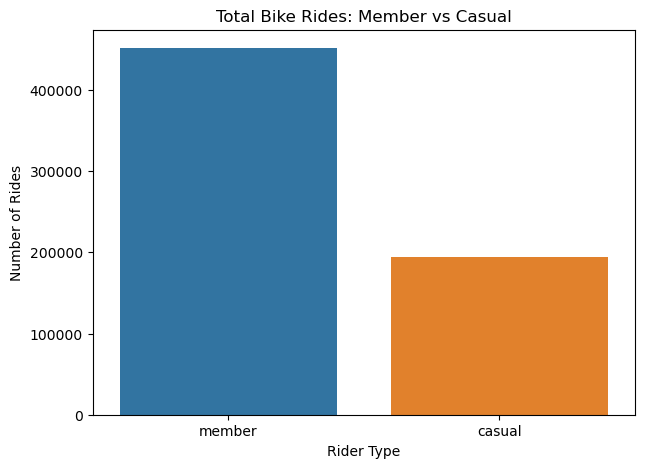

In [36]:
plt.figure(figsize=(7, 5))
sns.countplot(
    data=df_clean,
    x="member_casual"
)

plt.title("Total Bike Rides: Member vs Casual")
plt.xlabel("Rider Type")
plt.ylabel("Number of Rides")
plt.show()

In [37]:
rider_percent = (
    df_clean["member_casual"]
    .value_counts(normalize=True)
    .mul(100)
    .reset_index()
)

rider_percent.columns = ["member_casual", "percentage"]

display(rider_percent)

,member_casual,percentage
0,member,69.930123
1,casual,30.069877


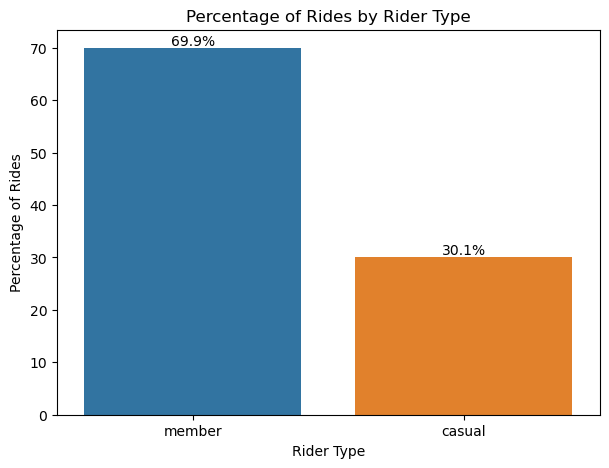

In [38]:
plt.figure(figsize=(7, 5))

ax = sns.barplot(
    data=rider_percent,
    x="member_casual",
    y="percentage"
)

plt.title("Percentage of Rides by Rider Type")
plt.xlabel("Rider Type")
plt.ylabel("Percentage of Rides")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.show()

# Analyzing Time Patterns

## Bike rentals by hour of the day

In [ ]:
hourly = (
    df_clean
    .groupby(["hour", "member_casual"])
    .size()
    .reset_index(name="rides")
)

display(hourly.head())

,hour,member_casual,rides
0,0,casual,3379
1,0,member,5071
2,1,casual,2231
3,1,member,3200
4,2,casual,1562


In [41]:
display(hourly.sample(5))

,hour,member_casual,rides
41,20,member,23169
5,2,member,2007
22,11,casual,10058
3,1,member,3200
45,22,member,13884


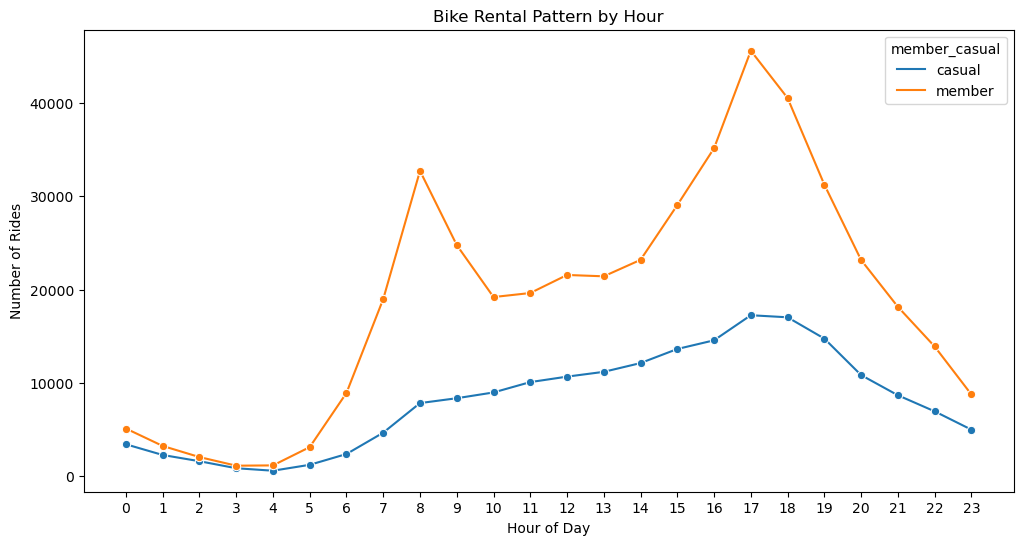

In [42]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=hourly,
    x="hour",
    y="rides",
    hue="member_casual",
    marker="o"
)

plt.title("Bike Rental Pattern by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Rides")
plt.xticks(range(24))
plt.show()

### Rentals by days of week

In [45]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_counts = (
    df_clean
    .groupby(["day_of_week", "member_casual"])
    .size()
    .reset_index(name="rides")
)
display(day_counts.head())

,day_of_week,member_casual,rides
0,Friday,casual,27754
1,Friday,member,62425
2,Monday,casual,24343
3,Monday,member,71548
4,Saturday,casual,44577


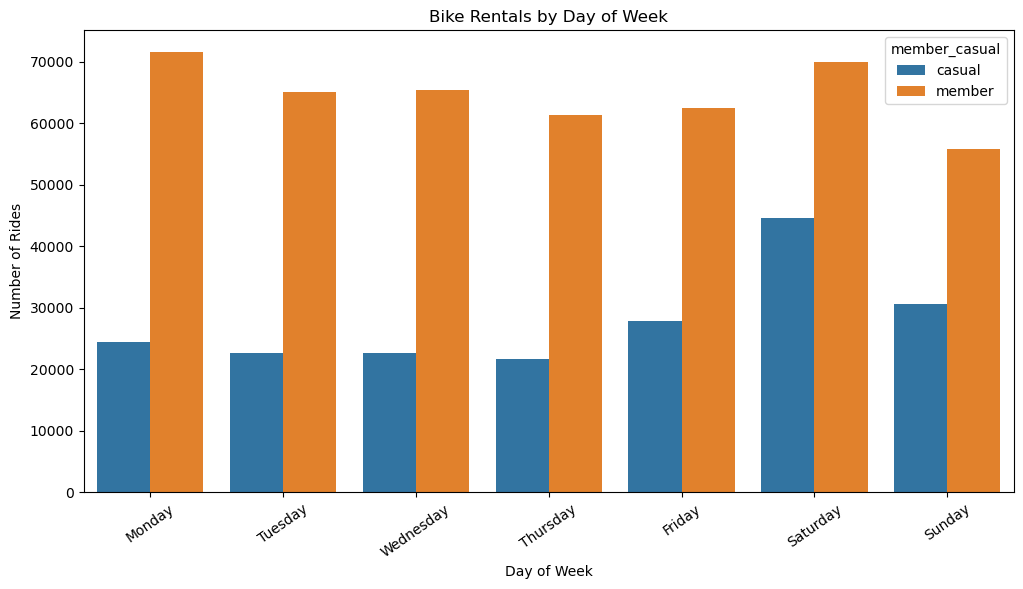

In [46]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=day_counts,
    x="day_of_week",
    y="rides",
    hue="member_casual",
    order=day_order
)

plt.title("Bike Rentals by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Rides")
plt.xticks(rotation=35)
plt.show()

## Average Daily usage: Weekday vs Weekend

In [47]:
daily_rides = (
    df_clean
    .groupby(["date", "day_type", "member_casual"])
    .size()
    .reset_index(name="rides")
)

display(daily_rides.head())

,date,day_type,member_casual,rides
0,2026-07-31,Weekday,casual,73
1,2026-07-31,Weekday,member,75
2,2026-08-01,Weekend,casual,9136
3,2026-08-01,Weekend,member,14026
4,2026-08-02,Weekend,casual,3679


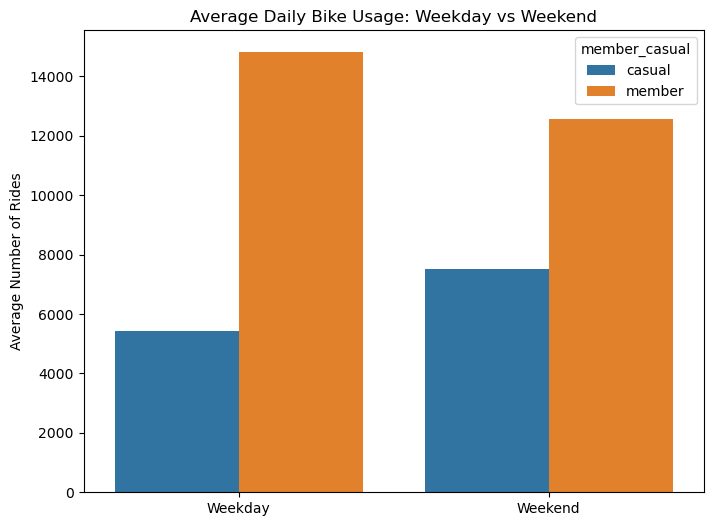

In [48]:
plt.figure(figsize=(8, 6))

sns.barplot(
    data=daily_rides,
    x="day_type",
    y="rides",
    hue="member_casual",
    errorbar=None
)

plt.title("Average Daily Bike Usage: Weekday vs Weekend")
plt.xlabel("")
plt.ylabel("Average Number of Rides")
plt.show()

## Inferences/ Insights

- The dataset was audited for missing values and duplicates, calculating both "Missing_Count" and "Missing_Percent" using sum(), isnull(), len(), and round(). An if statement was used to check for the presence of the ride_id column and print the total count of duplicate ride IDs found.

- Ride duration was calculated in minutes along with time components including start, end, duration, hour, day of the week, month, and date.
- The dataset was filtered to retain only ride durations between 0 and 1,440 minutes, outputting the row count before and after cleaning.

- A bar graph of total rides revealed that members accounted for 69.9% of rentals while casual riders made up 30.1%.
- Analysis of member versus casual ride counts showed that casual ride volume was twice as large as member ride volume.
- A comparison of overall rider percentages indicated that the casual rider segment was 40% larger than the member segment.
- Hourly rental patterns showed overall ride volume plotted against time of day, with casual rider usage reaching its peak between 7:00 AM and 8:00 AM.
- Analysis of rental timing demonstrated higher total ride volume on weekends compared to weekdays.